In [1]:
# Install Dependencies
%pip install evaluate datasets matplotlib optuna torchinfo transformers seaborn scikit-learn --quiet
%pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_mac

In [2]:
# Imports
import torch
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import load_dataset
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import optuna
from peft import get_peft_model, LoraConfig, TaskType
from torchinfo import summary
from transformers import TrainerCallback


In [3]:
# Load Dataset
dataset = load_dataset("imdb")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Label classes: ['neg', 'pos']
Train dataset size: 25000
Test dataset size: 25000


/tmp/ipython-input-4-1785585301.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=label_df, x="Sentiment", palette="pastel")


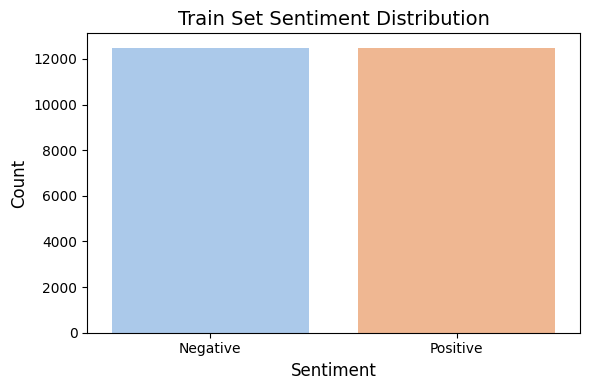

In [4]:
# EDA
import pandas as pd

# Checking label structure and dataset sizes
print("Label classes:", dataset['train'].features['label'].names)
print("Train dataset size:", len(dataset['train']))
print("Test dataset size:", len(dataset['test']))

# Converting labels to DataFrame for seaborn
label_map = {0: "Negative", 1: "Positive"}
train_labels = [label_map[label] for label in dataset['train']['label']]
label_df = pd.DataFrame(train_labels, columns=["Sentiment"])

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=label_df, x="Sentiment", palette="pastel")
plt.title("Train Set Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [5]:
#Show Class Imbalance
from collections import Counter

counter = Counter(dataset["train"]["label"])
total = sum(counter.values())
print("\nClass distribution:")
for label, count in counter.items():
    name = label_map[label]
    print(f"{name}: {count} ({count / total:.2%})")



Class distribution:
Negative: 12500 (50.00%)
Positive: 12500 (50.00%)


In [6]:
# Tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=512)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

# Select only 2,000 examples for training (IMDb has 25,000 total)
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(2000))
# Do the same for the test set, selecting only 1,000 examples
test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [20]:
# Metrics
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=preds, references=labels)
    return acc


In [21]:
# Model Init with PEFT LoRA
def model_init():
    model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        bias="none"
    )
    model = get_peft_model(model, lora_config)
    return model

In [22]:
# Hyperparameter Search Space
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 5, 6),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3),
    }

In [23]:
# Training Arguments
training_args = TrainingArguments(
    output_dir="./results_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_dir='./logs_lora',
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none"
)


In [24]:
# Trainer
trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [25]:
# Hyperparameter Tuning
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=3,
    compute_objective=lambda metrics: metrics["eval_accuracy"],
)

print("Best run:", best_run)

[I 2025-07-09 04:28:16,363] A new study created in memory with name: no-name-afc3bb4d-84a4-462f-8f62-f45dba8edec6
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.678900,0.621804,0.724000
2,0.477600,0.363969,0.850000
3,0.322600,0.408887,0.843000
4,0.311200,0.371238,0.859000
5,0.301800,0.363559,0.864000
6,0.294800,0.361716,0.866000


[I 2025-07-09 04:45:47,312] Trial 0 finished with value: 0.866 and parameters: {'learning_rate': 4.284849030798143e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 6, 'weight_decay': 0.005058155822822374}. Best is trial 0 with value: 0.866.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.688700,0.672450,0.636000
2,0.654400,0.604108,0.728000
3,0.527500,0.472593,0.775000
4,0.410200,0.388806,0.830000
5,0.353600,0.362518,0.847000
6,0.344900,0.364733,0.845000


[I 2025-07-09 05:03:19,776] Trial 1 finished with value: 0.845 and parameters: {'learning_rate': 2.3956047332144574e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 6, 'weight_decay': 0.29801663671312917}. Best is trial 0 with value: 0.866.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.683900,0.649483,0.689000
2,0.561000,0.429623,0.809000
3,0.372100,0.403836,0.837000
4,0.327400,0.357005,0.856000
5,0.315000,0.350626,0.868000


[I 2025-07-09 05:17:55,037] Trial 2 finished with value: 0.868 and parameters: {'learning_rate': 3.5754674449504516e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 5, 'weight_decay': 0.29130618904771666}. Best is trial 2 with value: 0.868.


Best run: BestRun(run_id='2', objective=0.868, hyperparameters={'learning_rate': 3.5754674449504516e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 5, 'weight_decay': 0.29130618904771666}, run_summary=None)


In [29]:
# Rebuild Trainer with Best Hyperparameters
best_args = best_run.hyperparameters
training_args = TrainingArguments(
    output_dir="./results_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=best_args["learning_rate"],
    per_device_train_batch_size=best_args["per_device_train_batch_size"],
    per_device_eval_batch_size=16,
    num_train_epochs=best_args["num_train_epochs"],
    weight_decay=best_args["weight_decay"],
    logging_dir='./logs_lora',
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none"
)

model = model_init()
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [31]:
class MetricsCallback(TrainerCallback):
    def __init__(self, trainer, train_dataset):
        self.trainer = trainer
        self.train_dataset = train_dataset
        self.eval_loss = []
        self.eval_accuracy = []
        self.train_loss = []
        self.train_accuracy = []
        self.epochs = []
        self._last_logged_epoch = -1

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None and state.epoch != self._last_logged_epoch:
            self.eval_loss.append(metrics.get("eval_loss"))
            self.eval_accuracy.append(metrics.get("eval_accuracy"))
            self.epochs.append(state.epoch)

            outputs = self.trainer.predict(self.train_dataset)
            preds = np.argmax(outputs.predictions, axis=1)
            labels = outputs.label_ids
            train_acc = np.mean(preds == labels)
            self.train_accuracy.append(train_acc)

            self._last_logged_epoch = state.epoch

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            self.train_loss.append(logs["loss"])

metrics_callback = MetricsCallback(trainer=trainer, train_dataset=train_dataset)
trainer.add_callback(metrics_callback)

In [32]:
# Fine-tune the model
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.683900,0.649483,0.689000
2,0.561000,0.429623,0.809000
3,0.372100,0.403836,0.837000
4,0.327400,0.357005,0.856000
5,0.315000,0.350626,0.868000


TrainOutput(global_step=1250, training_loss=0.45188373413085936, metrics={'train_runtime': 1502.2772, 'train_samples_per_second': 6.657, 'train_steps_per_second': 0.832, 'total_flos': 2640217497600000.0, 'train_loss': 0.45188373413085936, 'epoch': 5.0})

In [33]:
# Save best model
trainer.save_model("./best_model_lora")

In [34]:
# Evaluation
eval_results = trainer.evaluate()
print("Evaluation results:", eval_results)


Evaluation results: {'eval_loss': 0.35062578320503235, 'eval_accuracy': 0.868, 'eval_runtime': 30.9298, 'eval_samples_per_second': 32.331, 'eval_steps_per_second': 2.037, 'epoch': 5.0}


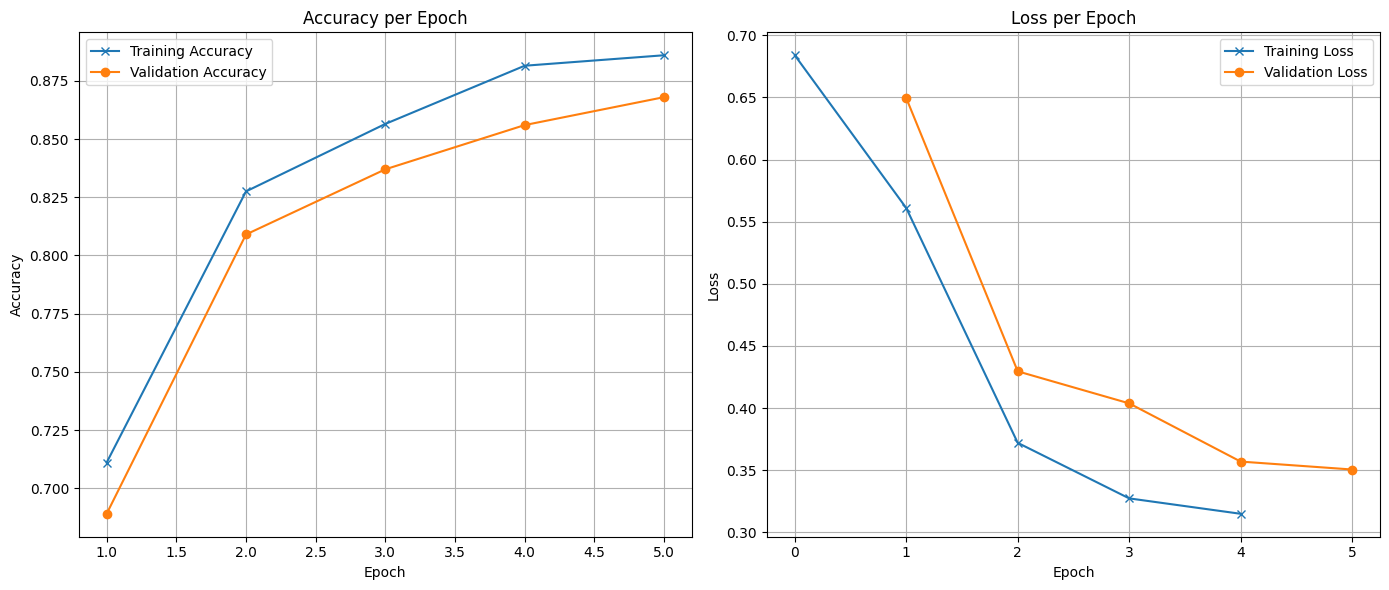

In [36]:
# Training & Validation Plots
epochs = metrics_callback.epochs

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, metrics_callback.train_accuracy, label="Training Accuracy", marker='x')
plt.plot(epochs, metrics_callback.eval_accuracy, label="Validation Accuracy", marker='o')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(metrics_callback.train_loss, label="Training Loss", marker='x')
plt.plot(epochs, metrics_callback.eval_loss, label="Validation Loss", marker='o')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87       512
           1       0.84      0.90      0.87       488

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



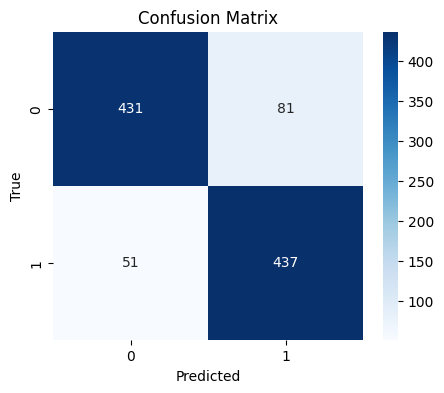

In [35]:
# Predictions & Confusion Matrix
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("\nClassification Report:\n", classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [37]:
# Prediction function
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(trainer.model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = trainer.model(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits).item()
    return "Positive" if pred == 1 else "Negative"

print("\nSample Predictions:")
print(predict_sentiment("This movie was good."))
print(predict_sentiment("ridiculous movie"))


Sample Predictions:
Positive
Negative


In [38]:
# Model Summary
dummy_input = torch.randint(0, tokenizer.vocab_size, (1, 512)).to(trainer.model.device)
print("\n--- Model Summary ---")
summary(trainer.model, input_data=dummy_input, device=str(trainer.model.device))


--- Model Summary ---


Layer (type:depth-idx)                                                 Output Shape              Param #
PeftModelForSequenceClassification                                     [1, 2]                    --
├─LoraModel: 1-1                                                       [1, 2]                    --
│    └─BertForSequenceClassification: 2-1                              --                        --
│    │    └─BertModel: 3-1                                             [1, 768]                  109,777,152
│    │    └─Dropout: 3-2                                               [1, 768]                  --
│    │    └─ModulesToSaveWrapper: 3-3                                  [1, 2]                    3,076
Total params: 109,780,228
Trainable params: 296,450
Non-trainable params: 109,483,778
Total mult-adds (Units.MEGABYTES): 109.78
Input size (MB): 0.00
Forward/backward pass size (MB): 504.11
Params size (MB): 439.11
Estimated Total Size (MB): 943.23

In [39]:
# Test Cases

test_inputs = [
    # Positive review
    ("An amazing film. Loved the characters, story, and visuals!", "Positive"),

    # Negative review
    ("Terrible movie. Boring plot and awful acting.", "Negative"),

    # Neutral/ambiguous review
    ("It was okay, not bad but nothing special either.", None),

    # Very short input
    ("Good!", "Positive"),

    # Empty input (should handle or warn)
    ("", "Invalid"),

    # Long input
    ("I really enjoyed this movie. " * 200, "Positive")
]

print("\n--- Running Test Cases ---")
for idx, (text, expected) in enumerate(test_inputs):
    try:
        prediction = predict_sentiment(text)
        result = "✅ Pass" if expected is None or prediction == expected else "❌ Fail"
        print(f"Test {idx + 1}: {result} | Input: {text[:60]}... | Predicted: {prediction} | Expected: {expected}")
    except Exception as e:
        print(f"Test {idx + 1}: ❌ Error | Input: {text[:60]}... | Error: {str(e)}")



--- Running Test Cases ---
Test 1: ✅ Pass | Input: An amazing film. Loved the characters, story, and visuals!... | Predicted: Positive | Expected: Positive
Test 2: ❌ Fail | Input: Terrible movie. Boring plot and awful acting.... | Predicted: Positive | Expected: Negative
Test 3: ✅ Pass | Input: It was okay, not bad but nothing special either.... | Predicted: Positive | Expected: None
Test 4: ✅ Pass | Input: Good!... | Predicted: Positive | Expected: Positive
Test 5: ❌ Fail | Input: ... | Predicted: Positive | Expected: Invalid
Test 6: ✅ Pass | Input: I really enjoyed this movie. I really enjoyed this movie. I ... | Predicted: Positive | Expected: Positive
